# This notebook is designed for execution in Google Colab and may require modification for local environments



# Mount Google Drive (Colab)

Connects Drive at /content/drive so dataset paths under MyDrive work. Approve the Google prompt when shown.

# Setup Environment & Paths

Install YOLO library and define where dataset is located (Drive → read, Local → write).

In [ ]:
!pip install ultralytics  # Install YOLOv8 library (run once)

import os       # Work with file paths and folders
import random   # Shuffle data randomly
import shutil   # Copy files between folders

# ---------- SOURCE (read from shared Google Drive) ----------
source_base = "/content/drive/MyDrive/Workshop on CRB Detection/Dataset"

# Path to images and labels inside dataset
images_dir = os.path.join(source_base, "images")
labels_dir = os.path.join(source_base, "labels")

# Path to YAML config file
yaml_path  = os.path.join(source_base, "crb.yaml")

# ---------- LOCAL DESTINATION (write locally for speed & permissions) ----------
base_dir = "/content/crb_dataset_local"

# Create base folder if not exists
os.makedirs(base_dir, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00


# Create Train/Val/Test Split Structure

Prepare folders and divide dataset into training, validation, and testing sets.

In [ ]:
# ---------- CREATE OUTPUT FOLDERS ----------
splits = ['train', 'val', 'test']  # Define dataset splits

# Create folders like train/images, train/labels, etc.
for split in splits:
    os.makedirs(os.path.join(base_dir, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(base_dir, split, "labels"), exist_ok=True)

# ---------- SPLIT RATIOS ----------
train_ratio = 0.7  # 70% for training
val_ratio   = 0.2  # 20% for validation
test_ratio  = 0.1  # 10% for testing

# ---------- GATHER & SHUFFLE ----------
# Get all image filenames (.jpg and .png only)
image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))]

# Fix randomness so everyone gets same split
random.seed(42)

# Shuffle image list randomly
random.shuffle(image_files)

# ---------- COMPUTE SPLIT ----------
total = len(image_files)  # Total number of images

# Calculate split indices
train_end = int(total * train_ratio)
val_end   = train_end + int(total * val_ratio)

# Slice the list into 3 parts
train_files = image_files[:train_end]
val_files   = image_files[train_end:val_end]
test_files  = image_files[val_end:]

# Copy Files & Finalize Dataset

Copy images + labels into split folders and prepare dataset for training.

In [ ]:
# ---------- COPY FUNCTION ----------
# Function to copy images and corresponding label files
def copy_split(files, split_name):
    for img_file in files:

        # Source image path (Drive)
        src_img = os.path.join(images_dir, img_file)

        # Destination image path (local)
        dst_img = os.path.join(base_dir, split_name, "images", img_file)

        # Copy image file
        shutil.copy(src_img, dst_img)

        # Find corresponding label (.txt)
        label_file = os.path.splitext(img_file)[0] + ".txt"

        # Source label path
        src_lbl = os.path.join(labels_dir, label_file)

        # Destination label path
        dst_lbl = os.path.join(base_dir, split_name, "labels", label_file)

        # Copy label if exists
        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, dst_lbl)

# Copy YAML file to local dataset folder
shutil.copy(
    os.path.join(source_base, "crb.yaml"),
    os.path.join(base_dir, "crb.yaml")
)

# ---------- RUN SPLITTING ----------
copy_split(train_files, "train")  # Copy training data
copy_split(val_files, "val")      # Copy validation data
copy_split(test_files, "test")    # Copy test data

# Print summary
print(f"Done! Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

Done! Train: 326, Val: 93, Test: 47


# Train YOLO Model

Train the YOLOv8 model using dataset configuration (crb.yaml) with selected parameters like epochs, image size, and batch size.

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")  # load pretrained YOLOv8 medium model

model.train(
    data=os.path.join(base_dir, "crb.yaml"),        # dataset config (paths + classes)
    epochs=10,              # Number of times the model sees the entire dataset cover-to-cover
    imgsz=640,              # image size for training
    batch=8,                # Number of images the model processes before updating its weights
    device="cuda",          # colab GPU is cuda (mac gpu is mps, don't set it here)
    project="crb_yolov8m",  # folder to save results
    name="run",             # run name inside project folder
    exist_ok=True           # overwrite existing run folder
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/crb_dataset_local/crb.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, i

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cd4309048c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

# Model Evaluation & Result Visualization

Load the trained YOLO model, evaluate it on the test dataset, and display the confusion matrix to understand performance.


Loading best model from: /content/runs/detect/crb_yolov8m/run/weights/best.pt
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 13.2±6.1 MB/s, size: 18.9 KB)
val: Scanning /content/crb_dataset_local/test/labels... 47 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 47/47 814.4it/s 0.1s
val: New cache created: /content/crb_dataset_local/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.9it/s 1.6s
                   all         47         97      0.866      0.624      0.751      0.483
                   crb         33         69      0.831      0.856      0.907      0.624
                  leaf         19         28      0.902      0.393      0.595      0.341
Speed: 4.9ms preprocess, 16.1ms inference, 0.0ms loss, 3.9ms postprocess per image
R

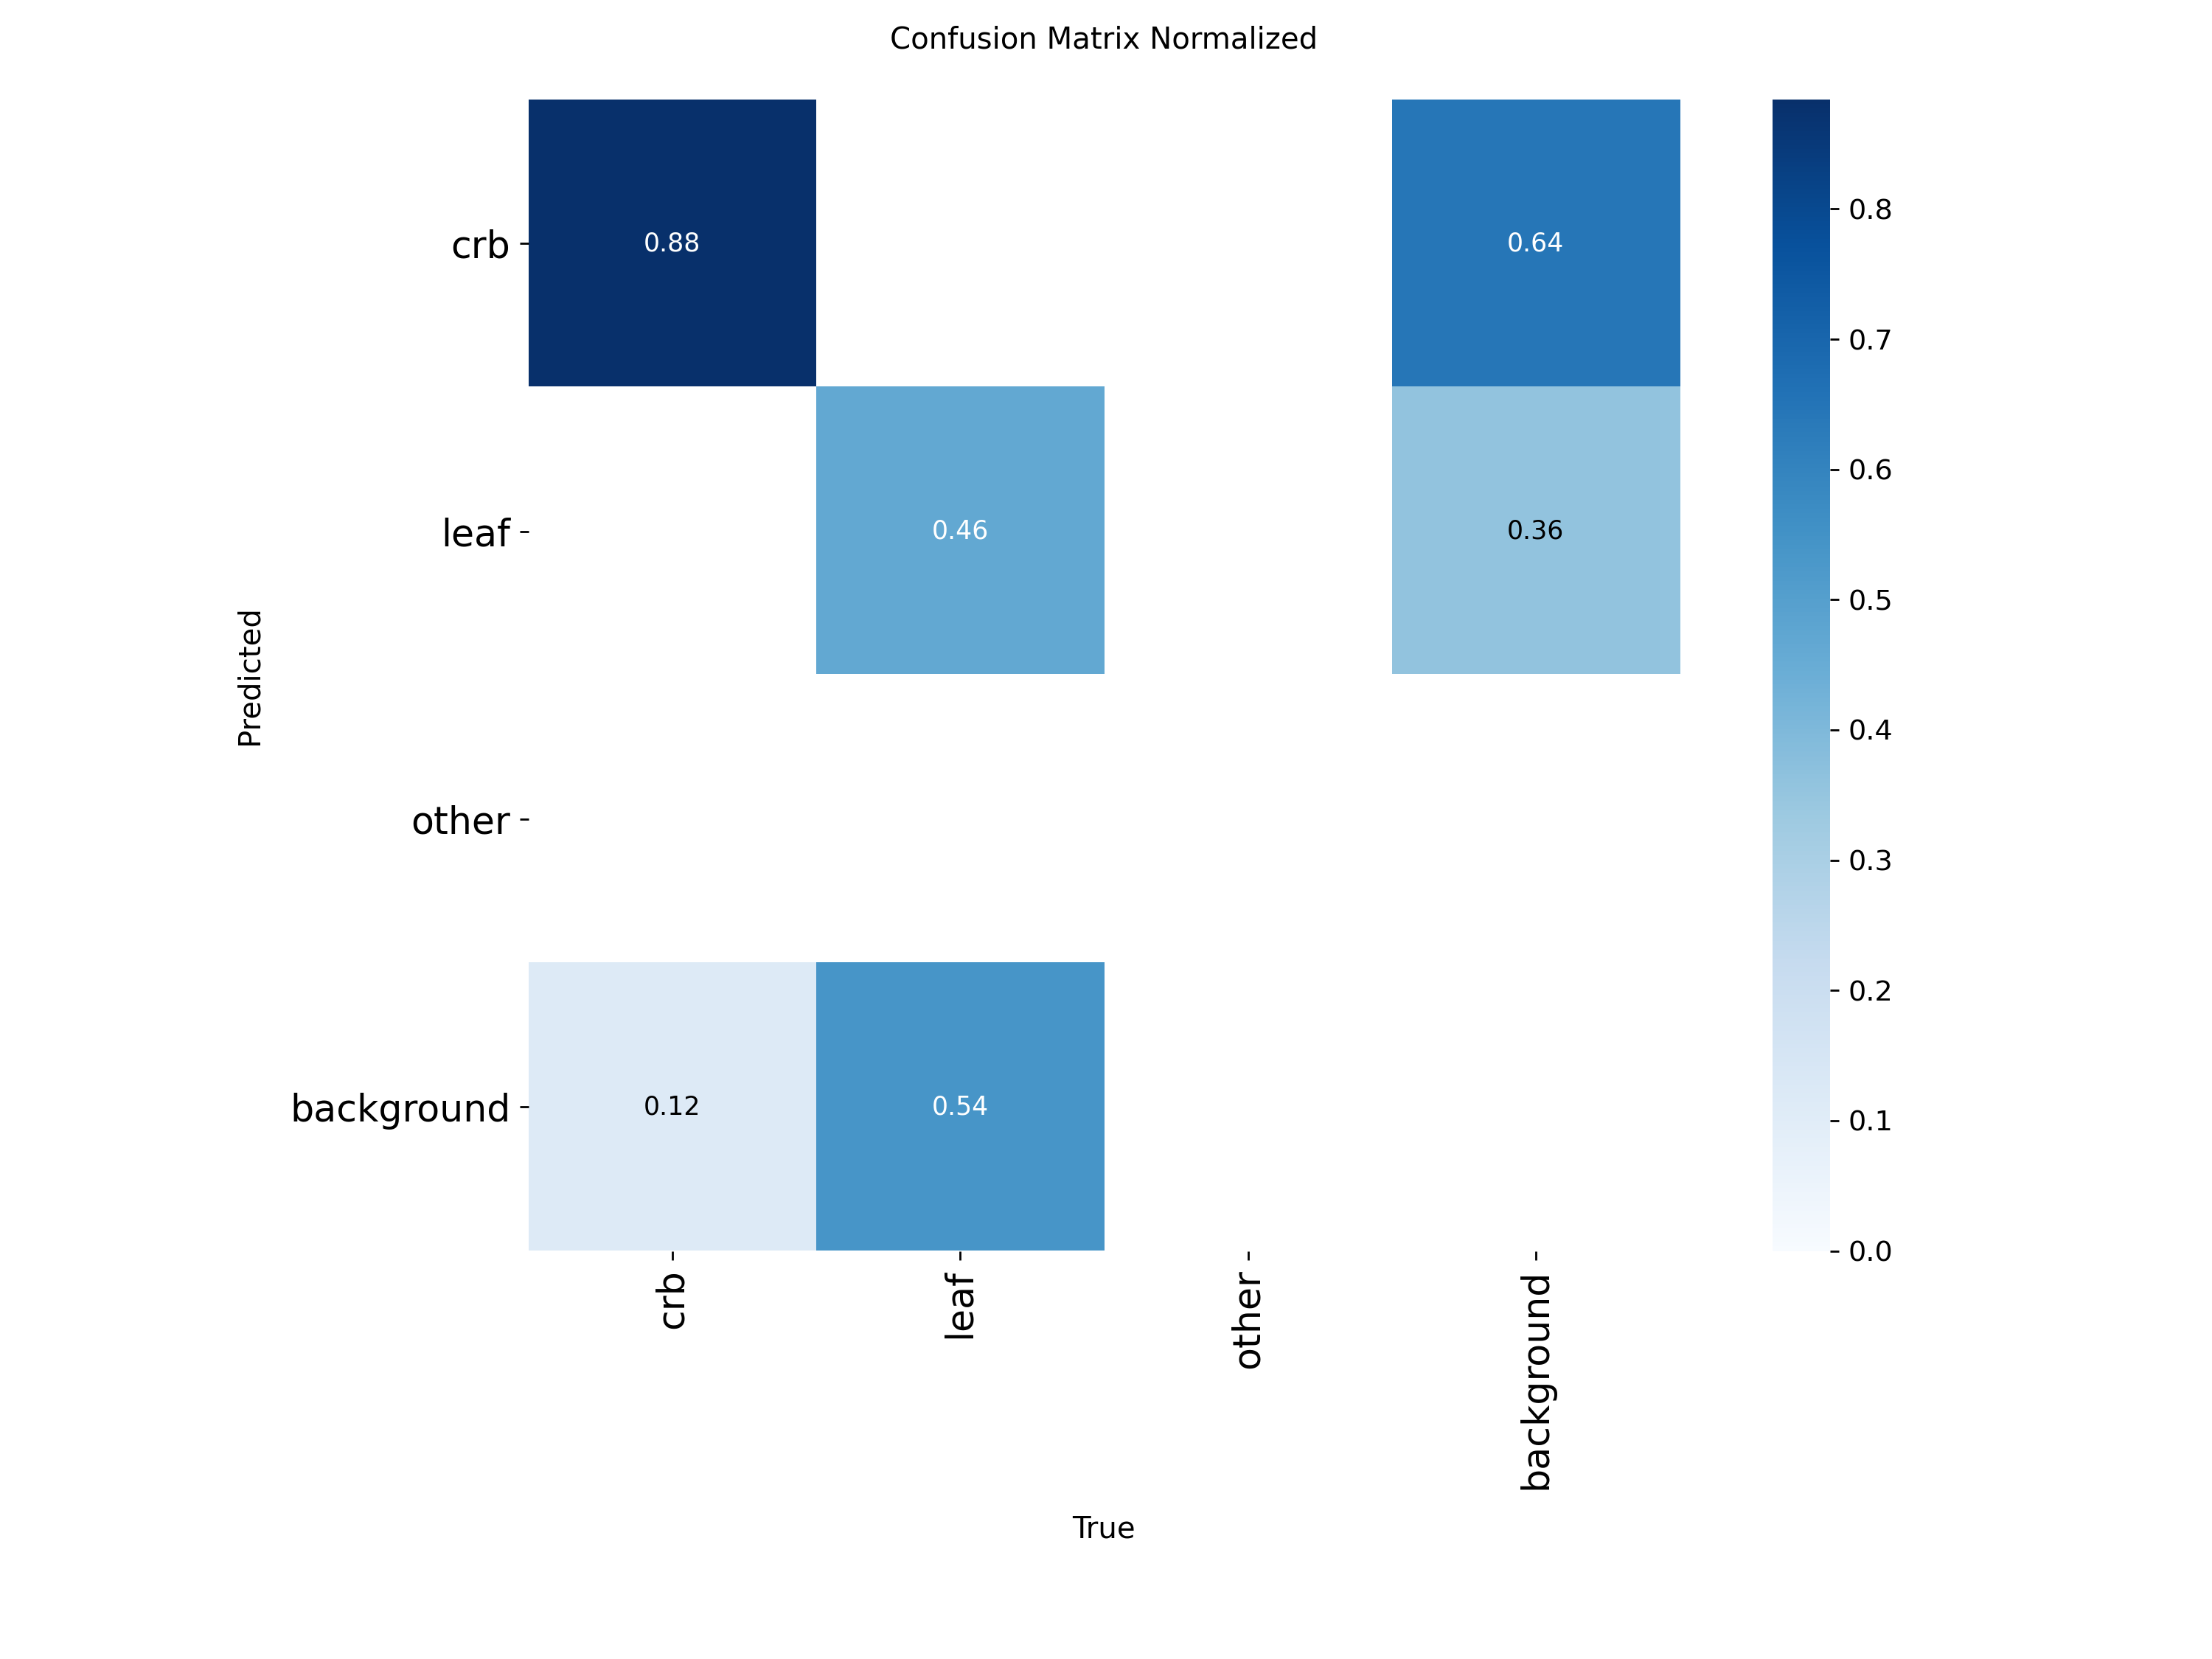

Normalized confusion matrix saved at: /content/runs/detect/val/confusion_matrix_normalized.png


In [ ]:
from ultralytics import YOLO  # Import YOLOv8 model class
import os                     # For handling file paths
from pathlib import Path      # For working with file paths cleanly
from IPython.display import Image, display  # To show images in Colab

# --------- SET BASE DIRECTORY ---------
# This should point to our LOCAL dataset folder
base_dir = "/content/crb_dataset_local"

# --------- LOAD TRAINED MODEL ---------
# Path to the best trained weights saved after training
best_weights = "/content/runs/detect/crb_yolov8m/run/weights/best.pt"

# Path to dataset configuration file (YAML)
data_yaml = os.path.join(base_dir, "crb.yaml")

print(f"Loading best model from: {best_weights}")

# Load trained YOLO model
model = YOLO(best_weights)

# --------- RUN VALIDATION ---------
# Evaluate model on test dataset and generate plots
test_results = model.val(
    data=data_yaml,   # Path to dataset YAML
    split="test",     # Use test dataset
    plots=True        # Save confusion matrix and metrics plots
)

# --------- FIND CONFUSION MATRIX ---------
# YOLO saves results in a directory; we retrieve that location
save_dir = getattr(test_results, "save_dir", None)

# Expected path of confusion matrix
cm_path = Path(save_dir) / "confusion_matrix_normalized.png" if save_dir else None

# --------- FALLBACK SEARCH ---------
# If not found, search entire /content directory
if not cm_path or not cm_path.is_file():
    found = list(Path("/content").rglob("confusion_matrix_normalized.png"))
    cm_path = max(found, key=lambda p: p.stat().st_mtime) if found else None

# --------- DISPLAY RESULT ---------
# Show confusion matrix image
if cm_path and cm_path.is_file():
    display(Image(filename=str(cm_path)))
    print(f"Normalized confusion matrix saved at: {cm_path}")
else:
    print("Confusion matrix not found. Check training/validation output.")